<a href="https://colab.research.google.com/github/joagli/Especialidad-AADD/blob/main/Tasca_S9_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tasca S9.01. Visualització de Dades amb Python i Power BI

## Nivell 1 - Visualització analítica guiada en Python

### Exercici 1: Preguntes analítiques directes

Aspectes a revisar i analitzar:

- Identificar quina informació és necessàriaQuin DataFrame és el més adequat per respondre la pregunta.

- Escollir correctament la taula (o taules) rellevant(s).

- Tipus de variables implicades.

- Elecció del tipus de gràfic.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos

df = pd.read_csv("N1-Ex.8__transactions.csv", sep=";")

# Editamos formatos de fecha y hora

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()
df["status"] = df["declined"].map({0: "Aceptada", 1: "Rechazada"})

print(f"Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Periodo: {df['timestamp'].min().date()} hasta {df['timestamp'].max().date()}")



Dataset: 100,000 filas × 22 columnas
Periodo: 2015-01-01 hasta 2024-12-31


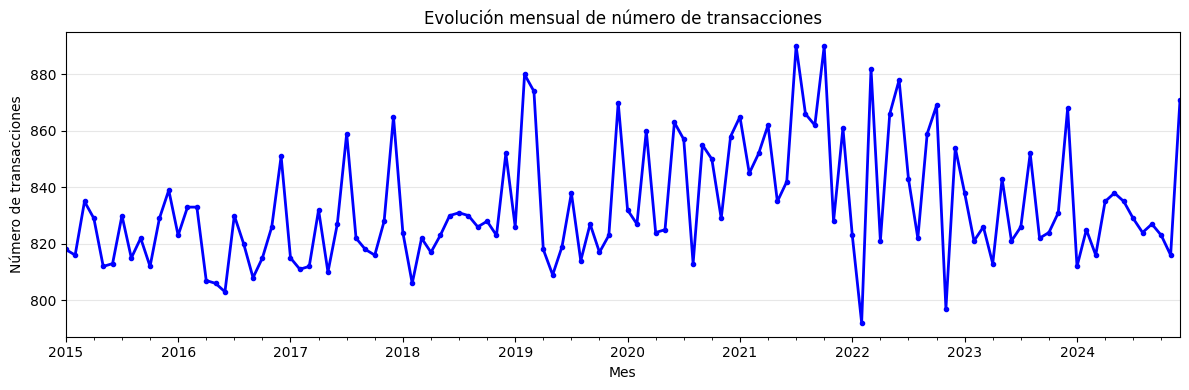

In [ ]:
# Evolución de número de transacciones en el tiempo

# Agrupamos por mes, contamos las transacciones y visualizamos la evolución

evolucion = (df.resample("ME", on="timestamp").size().rename("num_transacciones"))

evolucion.plot(
    kind="line",
    figsize=(12, 4),
    title="Evolución mensual de número de transacciones",
    color="blue",
    linewidth=2,
    marker="o",
    markersize=3
)
plt.xlabel("Mes")
plt.ylabel("Número de transacciones")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

"""Interpretación: Hay una tendencia general estable en el número de
transacciones a lo largo del todo el periodo mostrado en el gráfico,
con fluctuaciones mensuales que podrían estar asociadas a estacionalidad.
No se aprecian caídas ni picos repentinos que sugieran anomalías puntuales
en el volumen de actividad."""


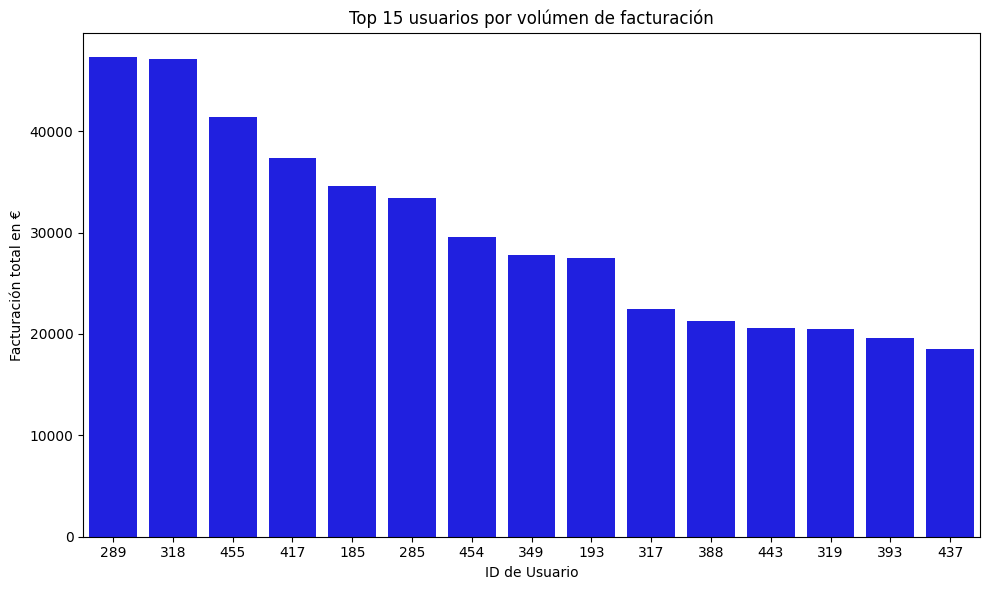

In [ ]:
# Usuarios que generan mayor volúmen de facturación

# Agrupamos por user_id, sumamos amount, ordenamos y seleccionamos el top 15

top_usuarios = (
    df.groupby("user_id")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

top_usuarios.columns = ["user_id", "facturacion_total"]

# Convertimos user_id a string para evitar que lo ordene por este número
top_usuarios["user_id"] = top_usuarios["user_id"].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_usuarios,
    x="user_id",
    y="facturacion_total",
    order=top_usuarios["user_id"], # Forzamos el orden
    color="blue"
)
plt.title("Top 15 usuarios por volúmen de facturación")
plt.xlabel("ID de Usuario")
plt.ylabel("Facturación total en €")
plt.tight_layout()
plt.show()

"""Interpretación: [Hi ha pocs usuaris que generen molt? Quina diferència entre
el 1r i el 15è?]. Existe una concentración de facturación en un grupo reducido
de usuarios, con una diferencia a destacar entre el 1º y el 15º puesto del ranking.
Esto indica que el negocio depende en cierta medida de clientes de alto valor,
lo que podría ser relevante para estrategias de retención"""


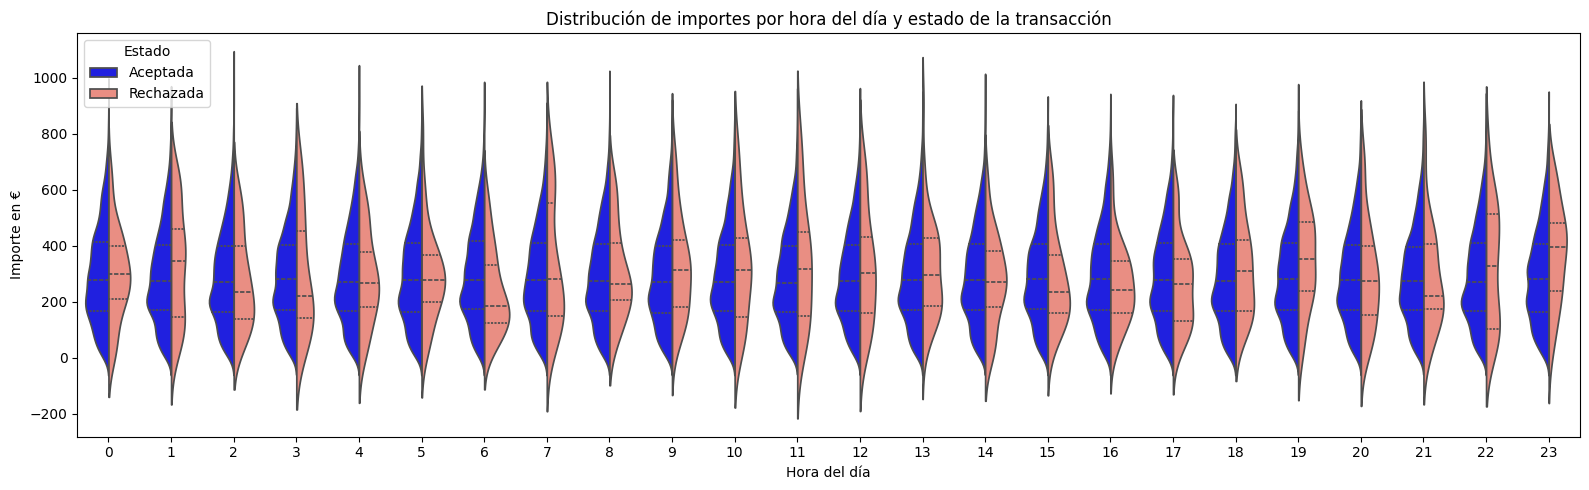

In [ ]:
# extraemos la hora del timestamp, visualizamos la distribución de importes
# por hora, separando aceptadas y rechazadas

# Filtramos para evitar un violin muy denso

plt.figure(figsize=(16, 5))
sns.violinplot(
    data=df,
    x="hour",
    y="amount",
    hue="status",
    split=True,
    inner="quartile",
    palette={"Aceptada": "blue", "Rechazada": "salmon"}
)
plt.title("Distribución de importes por hora del día y estado de la transacción")
plt.xlabel("Hora del día")
plt.ylabel("Importe en €")
plt.legend(title="Estado")
plt.tight_layout()
plt.show()

"""Interpretación: [Hi ha hores on els imports rebutjats són més alts? Patrons
de frau?]. Se observan algunas franjas horarias donde los montos rechazados
presentan una dispersión o mediana distinta a los aceptados, lo que podría
significar patrones de riesgo o fraude concentrados en horas concretas del día,
por ejemplo, en la madrugada."""


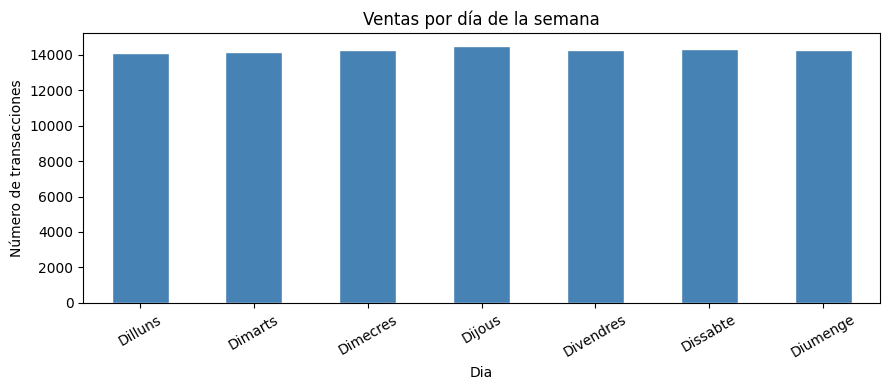

In [ ]:
# Extraemos el día de la semana, contamos transacciones y ordenamos cronológicamente

orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
traduccion = {"Monday": "Dilluns", "Tuesday": "Dimarts", "Wednesday": "Dimecres",
              "Thursday": "Dijous", "Friday": "Divendres", "Saturday": "Dissabte", "Sunday": "Diumenge"}

actividad_dia = (
    df["day_of_week"]
    .value_counts()
    .reindex(orden_dias)
    .rename(index=traduccion)
)

actividad_dia.plot(
    kind="bar",
    figsize=(9, 4),
    title="Ventas por día de la semana",
    color="steelblue",
    edgecolor="white"
)
plt.xlabel("Dia")
plt.ylabel("Número de transacciones")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

"""Interpretación: [Quin dia té més activitat? El cap de setmana cau o puja?]
La actividad es un poco más alta los jueves, pero no significativamente, el
fin de semana no tiene un cambio significativo."""


### Exercici 2: Preguntes analítiques complexes (amb guia)

Aquí sí que serà necessari:

- Fer merge entre taules.

- Utilitzar groupby, pivot_table, crosstab...

- Aplicar agregacions, transformacions intermèdies i funcions.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos las tres tablas

transactions = pd.read_csv("N1-Ex.8__transactions.csv", sep=";")
companies = pd.read_csv("N1-Ex.8__companies.csv")
products = pd.read_csv("N1-Ex.8__products.csv")

# Parseamos los timestamps

transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])
transactions["year"] = transactions["timestamp"].dt.year
transactions["month"] = transactions["timestamp"].dt.month
transactions["hour"] = transactions["timestamp"].dt.hour

print("Transactions:", transactions.shape)
print("Companies:   ", companies.shape)
print("Products:    ", products.shape)
print("Columnas Transactions:", transactions.columns.tolist())
print("Columnas Companies:", companies.columns.tolist())
print("Columnas Products:", products.columns.tolist())



Transactions: (100000, 22)
Companies:    (100, 8)
Products:     (100, 10)
Columnas Transactions: ['id', 'card_id', 'business_id', 'timestamp', 'amount', 'declined', 'product_ids', 'user_id', 'lat', 'longitude', 'discount_amount', 'tax_amount', 'shipping_amount', 'channel', 'campaign_id', 'device_type', 'is_international', 'decline_reason', 'distance_km', 'year', 'month', 'hour']
Columnas Companies: ['company_id', 'company_name', 'phone', 'email', 'country', 'website', 'merchant_category', 'merchant_price_position']
Columnas Products: ['id', 'product_name', 'price', 'colour', 'weight', 'warehouse_id', 'category', 'brand', 'cost', 'launch_date']


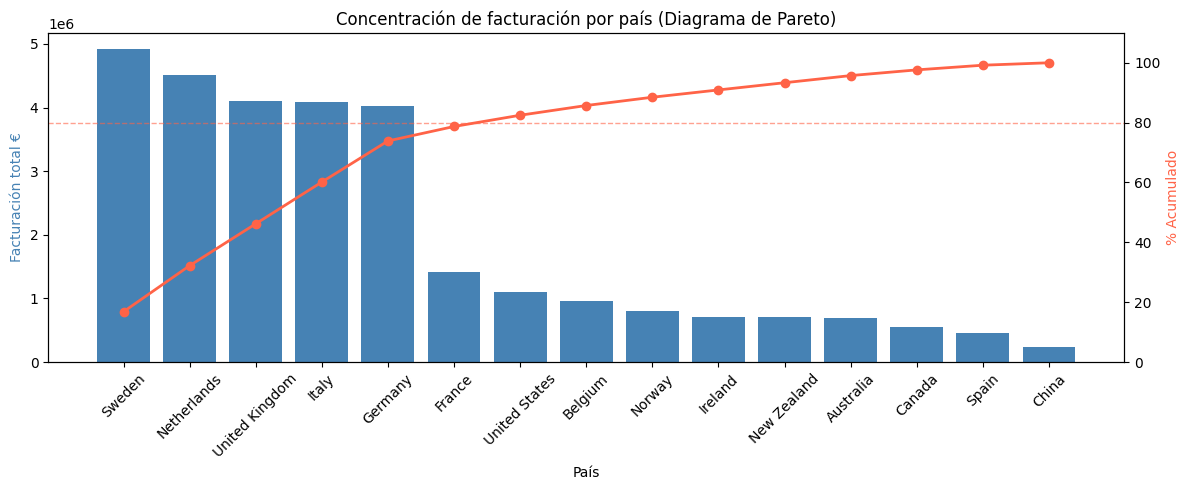

In [ ]:
# Depenem excessivament d'un nombre reduït de països de companyies venedores?

# Merge transactions con companies en business_id = company_id

df_pais = transactions.merge(companies, left_on="business_id", right_on="company_id", how="left")

# Facturación total por país

facturacion_pais = (
    df_pais.groupby("country")["amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Porcentaje acumulado

facturacion_pais["pct_acumulado"] = (
    facturacion_pais["amount"].cumsum() / facturacion_pais["amount"].sum() * 100
)

# Gráfico barras + línea con acumulado (Pareto)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(facturacion_pais["country"], facturacion_pais["amount"], color="steelblue")
ax1.set_xlabel("País")
ax1.set_ylabel("Facturación total €", color="steelblue")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(facturacion_pais["country"], facturacion_pais["pct_acumulado"],
         color="tomato", marker="o", linewidth=2)
ax2.axhline(80, color="tomato", linestyle="--", linewidth=1, alpha=0.6)
ax2.set_ylabel("% Acumulado", color="tomato")
ax2.set_ylim(0, 110)

plt.title("Concentración de facturación por país (Diagrama de Pareto)")
plt.tight_layout()
plt.show()

"""Un número reducido de países concentra la mayor parte de la facturación,
la curva acumulada supera el 80% rápidamente, esto muestra que dependencia en
pocos mercados clave"""

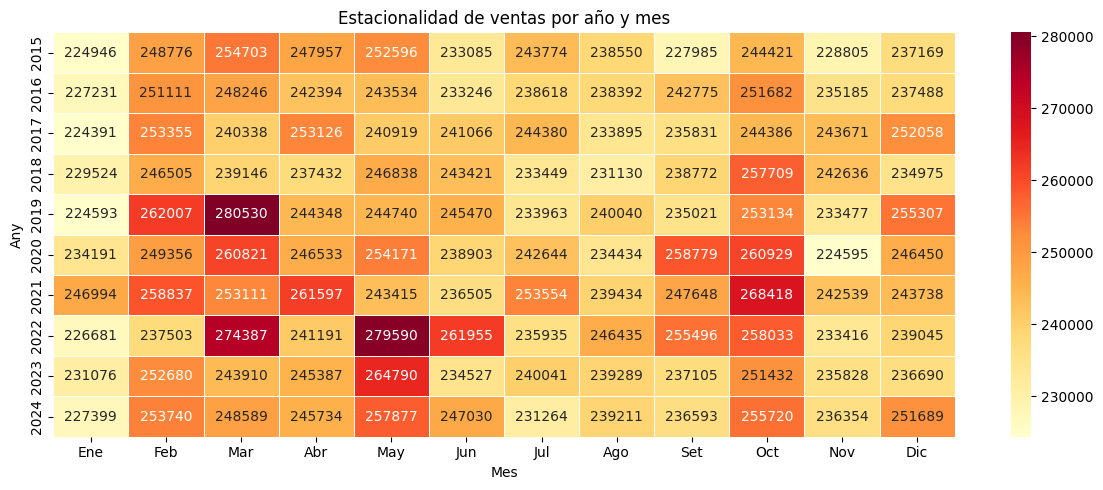

In [ ]:
# Existeix estacionalitat en les vendes?

# Total por año y mes

ventas_mensuales = (
    transactions.groupby(["year", "month"])["amount"]
    .sum()
    .reset_index()
)

# Pivot: filas = year, columnas = month

pivot_estacionalidad = ventas_mensuales.pivot(
    index="year", columns="month", values="amount"
)

# Abreviamos los meses

pivot_estacionalidad.columns = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Set", "Oct", "Nov", "Dic"
]

# Mapa de calor

plt.figure(figsize=(12, 5))
sns.heatmap(
    pivot_estacionalidad,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Estacionalidad de ventas por año y mes")
plt.xlabel("Mes")
plt.ylabel("Any")
plt.tight_layout()
plt.show()

""" Sí existe cierta estacionalidad, con meses puntuales con mayor
facturación que se repiten en distintos años, pero no es un patrón
uniforme."""

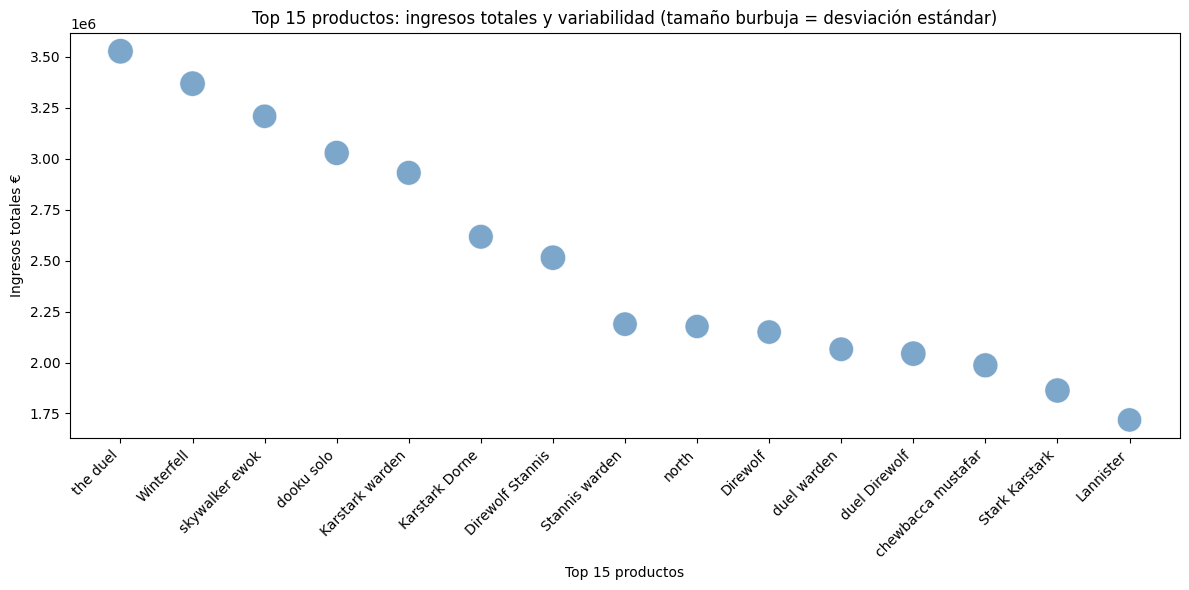

In [ ]:
# Anàlisi de concentració i variabilitat (tria UNA opció)
# Opció A – Producte (Només si disposes de la taula de productes)

# Separamos los productos individualmente de la columna product_ids

df_prod = transactions[["product_ids", "amount"]].copy()
df_prod["product_ids"] = df_prod["product_ids"].astype(str).str.split(",")
df_prod = df_prod.explode("product_ids")
df_prod["product_ids"] = df_prod["product_ids"].str.strip()
df_prod = df_prod[df_prod["product_ids"].notna() & (df_prod["product_ids"] != "") & (df_prod["product_ids"] != "nan")]
df_prod["product_ids"] = df_prod["product_ids"].astype(int)

# Unimos con la tabla productos

df_prod = df_prod.merge(
    products,
    left_on="product_ids",
    right_on="id",
    how="left"
)

# Ingreso total más variabilidad por producto

ingresos_prod = (
    df_prod.groupby("product_name")["amount"]
    .agg(total="sum", variabilidad="std")
    .sort_values("total", ascending=False)
    .head(15)
    .reset_index()
)

# Gráfico de burbujas

plt.figure(figsize=(12, 6))
plt.scatter(
    range(len(ingresos_prod)),
    ingresos_prod["total"],
    s=ingresos_prod["variabilidad"] * 2,
    color="steelblue", alpha=0.7,
    edgecolors="white", linewidth=0.5
)
plt.xticks(
    range(len(ingresos_prod)),
    ingresos_prod["product_name"],
    rotation=45, ha="right"
)
plt.xlabel("Top 15 productos")
plt.ylabel("Ingresos totales €")
plt.title("Top 15 productos: ingresos totales y variabilidad (tamaño burbuja = desviación estándar)")
plt.tight_layout()
plt.show()

"""Los productos top no solo generan más ingresos, sino que algunos también
muestran un poco más de variabilidad, lo que sugiere ventas menos predecibles
en esos casos."""

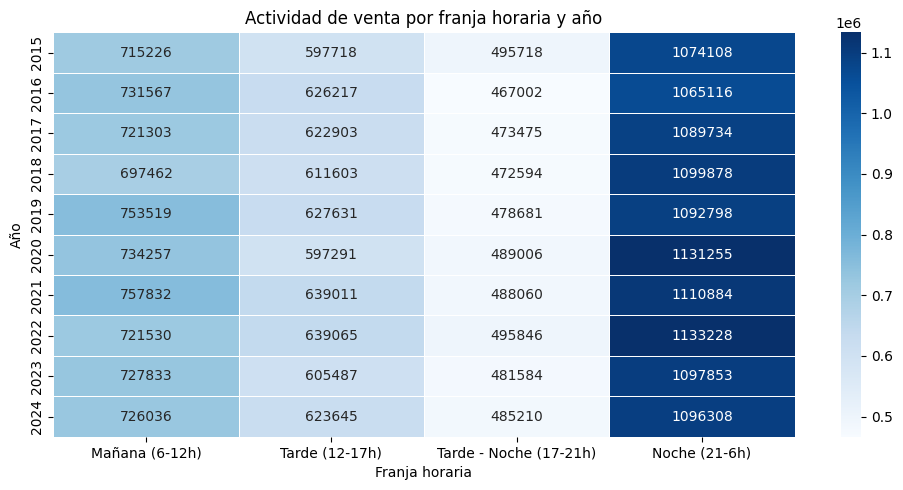

In [ ]:
# Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)

# Definimos las franjas horarias

def franja_horaria(hora):
    if 6 <= hora < 12:
        return "Mañana (6-12h)"
    elif 12 <= hora < 17:
        return "Tarde (12-17h)"
    elif 17 <= hora < 21:
        return "Tarde - Noche (17-21h)"
    else:
        return "Noche (21-6h)"

transactions["franja"] = transactions["hour"].apply(franja_horaria)

# Crosstab: filas = año, columnas = franja horaria

orden_franjas = ["Mañana (6-12h)", "Tarde (12-17h)", "Tarde - Noche (17-21h)", "Noche (21-6h)"]

ct = pd.crosstab(
    transactions["year"],
    transactions["franja"],
    values=transactions["amount"],
    aggfunc="sum"
)[orden_franjas]

# Mapa de calor

plt.figure(figsize=(10, 5))
sns.heatmap(
    ct,
    annot=True, fmt=".0f",
    cmap="Blues",
    linewidths=0.5
)
plt.title("Actividad de venta por franja horaria y año")
plt.xlabel("Franja horaria")
plt.ylabel("Año")
plt.tight_layout()
plt.show()

"""La actividad se concentra en las franjas horarias de forma consistente año
tras año, esto indica un patrón de comportamiento estable de los usuarios."""

## Nivell 2 – Anàlisi relacional i patrons avançats

### Exercici 1: Anàlisi de productes i captació d'usuaris

Objectiu: Analitzar el rendiment dels productes combinant ingressos, estabilitat i capacitat de captació de nous usuaris, amb l'objectiu de detectar possibles riscos de negoci associats a concentració excessiva d'ingressos, dependència d'usuaris recurrents i manca de creixement en base d'usuaris.

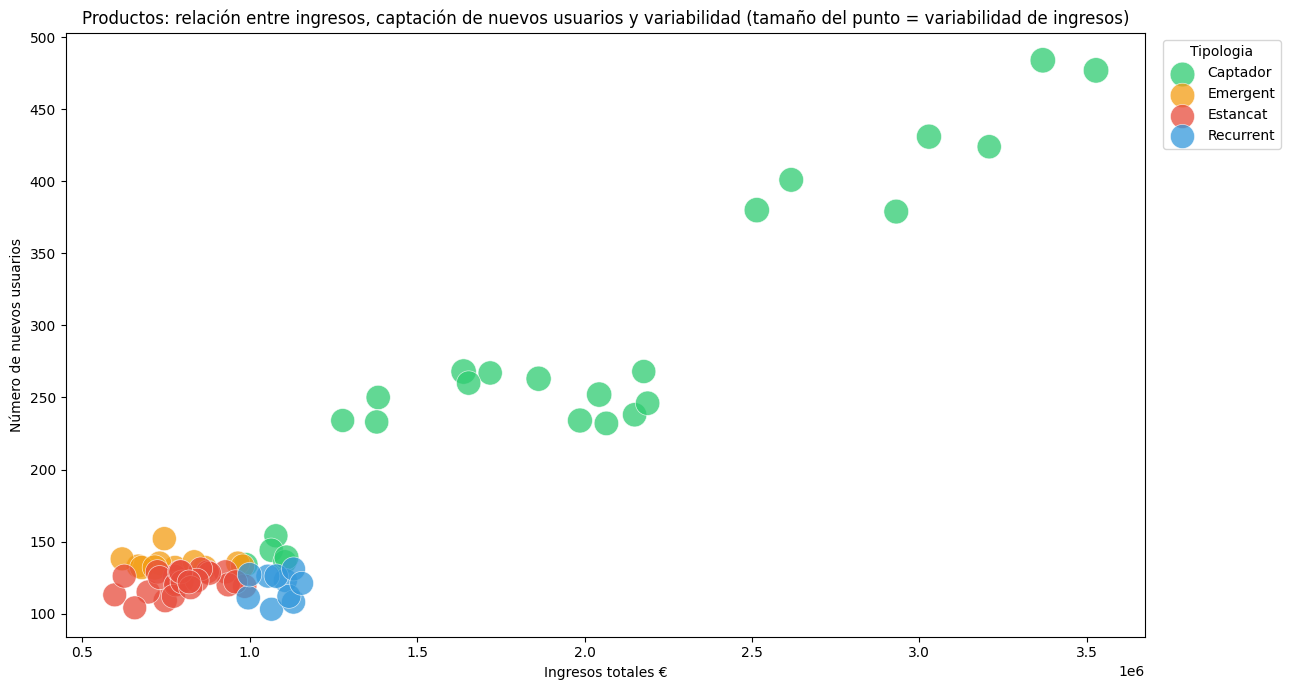

In [ ]:
# Extraemos los product_ids y los unimos con products

df_n2 = transactions[["id", "user_id", "amount", "timestamp", "product_ids"]].copy()
df_n2["product_ids"] = df_n2["product_ids"].astype(str).str.split(",")
df_n2 = df_n2.explode("product_ids")
df_n2["product_ids"] = df_n2["product_ids"].str.strip()
df_n2 = df_n2[df_n2["product_ids"].notna() & (df_n2["product_ids"] != "") & (df_n2["product_ids"] != "nan")]
df_n2["product_ids"] = df_n2["product_ids"].astype(int)

df_n2 = df_n2.merge(
    products[["id", "product_name"]],
    left_on="product_ids",
    right_on="id",
    how="left"
).drop(columns="id_y").rename(columns={"id_x": "transaction_id"})

# Marcamos la primera transacción cronologicamente

df_n2["timestamp"] = pd.to_datetime(df_n2["timestamp"])
primera_compra = (
    transactions.groupby("user_id")["timestamp"]
    .min()
    .reset_index()
    .rename(columns={"timestamp": "primera_fecha"})
)
primera_compra["primera_fecha"] = pd.to_datetime(primera_compra["primera_fecha"])

df_n2 = df_n2.merge(primera_compra, on="user_id", how="left")
df_n2["nuevo_usuario"] = df_n2["timestamp"] == df_n2["primera_fecha"]

# Totalizamos por producto

agg = df_n2.groupby("product_name").agg(
    ingresos_totales=("amount", "sum"),
    variabilidad=("amount", "std"),
    nuevos_usuarios=("nuevo_usuario", "sum"),
    total_compradores=("user_id", "nunique")
).reset_index()

agg["pct_nuevos_usuarios"] = agg["nuevos_usuarios"] / agg["total_compradores"] * 100

# Definimos tipología de productos

mediana_ingresos = agg["ingresos_totales"].median()
mediana_nuevos      = agg["nuevos_usuarios"].median()

def tipologia(row):
    alt_ing = row["ingresos_totales"] >= mediana_ingresos
    alt_nuevo = row["nuevos_usuarios"] >= mediana_nuevos
    if alt_ing and alt_nuevo:
        return "Captador"
    elif alt_ing and not alt_nuevo:
        return "Recurrent"
    elif not alt_ing and alt_nuevo:
        return "Emergent"
    else:
        return "Estancat"

agg["tipologia"] = agg.apply(tipologia, axis=1)

# Gráfico de dispersión

colors = {
    "Captador":  "#2ecc71",
    "Recurrent": "#3498db",
    "Emergent":  "#f39c12",
    "Estancat":  "#e74c3c"
}

plt.figure(figsize=(13, 7))

for tipos, grupo in agg.groupby("tipologia"):
    plt.scatter(
        grupo["ingresos_totales"],
        grupo["nuevos_usuarios"],
        s=grupo["variabilidad"].fillna(0) * 2,
        color=colors[tipos],
        alpha=0.75,
        edgecolors="white",
        linewidth=0.5,
        label=tipos
    )

plt.xlabel("Ingresos totales €")
plt.ylabel("Número de nuevos usuarios")
plt.title(
    "Productos: relación entre ingresos, captación de nuevos usuarios y variabilidad "
    "(tamaño del punto = variabilidad de ingresos)",
    fontsize=12
)
plt.legend(title="Tipologia", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

"""La mayoría de los productos se agrupan como "Recurrent" o "Estancat", mientras
que pocos productos logran ser "Captador" (altos ingresos y alta captación de
nuevos usuarios a la vez). Esto nos indica que el crecimiento de la base
de usuarios depende de un grupo pequeño de productos."""


### Exercici 2: Anàlisi geogràfica company–usuari i oportunitats d'expansió

Objectiu: Analitzar la relació entre el país de les companyies venedores, el país de residència dels usuaris i el flux de compra entre països.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos las tablas

df_transactions = pd.read_csv("N1-Ex.8__transactions.csv", sep=";")
df_companies    = pd.read_csv("N1-Ex.8__companies.csv")

print(df_transactions.columns.tolist())
print()
print(df_companies.columns.tolist())


['id', 'card_id', 'business_id', 'timestamp', 'amount', 'declined', 'product_ids', 'user_id', 'lat', 'longitude', 'discount_amount', 'tax_amount', 'shipping_amount', 'channel', 'campaign_id', 'device_type', 'is_international', 'decline_reason', 'distance_km']

['company_id', 'company_name', 'phone', 'email', 'country', 'website', 'merchant_category', 'merchant_price_position']


In [ ]:
# Unimos transactions con companies y creamos compra_local

def crear_geo_df(df_tx, df_comp):
    df = df_tx.merge(df_comp[['company_id', 'country']],
                     left_on='business_id',
                     right_on='company_id',
                     how='left')
    df.rename(columns={'country': 'company_country'}, inplace=True)

# Usamos columna is_international para identificar transacciones locales/internacionales

    df['compra_local'] = df['is_international'] == 0
    return df

df_geo = crear_geo_df(df_transactions, df_companies)
print(df_geo[['business_id', 'company_country', 'is_international', 'compra_local']].head())


  business_id company_country  is_international  compra_local
0      b-2466           Spain                 0          True
1      b-2342          Sweden                 0          True
2      b-2250           Italy                 1         False
3      b-2610           Italy                 0          True
4      b-2454           Italy                 0          True


In [ ]:
# % Global de transacciones e ingresos locales vs internacionales

def analisis_global_local(df):
    total_tx = len(df)
    monto_total = df['amount'].sum()

    resumen = df.groupby('compra_local').agg(
        num_transacciones = ('id', 'count'),
        ingreso_total = ('amount', 'sum')
    ).reset_index()

    resumen['pct_transacciones'] = (resumen['num_transacciones'] / total_tx * 100).round(2)
    resumen['pct_ingresos']      = (resumen['ingreso_total'] / monto_total * 100).round(2)
    resumen['compra_local']     = resumen['compra_local'].map({True: 'Local', False: 'International'})
    return resumen

resumen_global = analisis_global_local(df_geo)
print(resumen_global)


    compra_local  num_transacciones  ingreso_total  pct_transacciones  \
0  International              15486     4293172.12              15.49   
1          Local              84514    25002302.23              84.51   

   pct_ingresos  
0         14.65  
1         85.35  


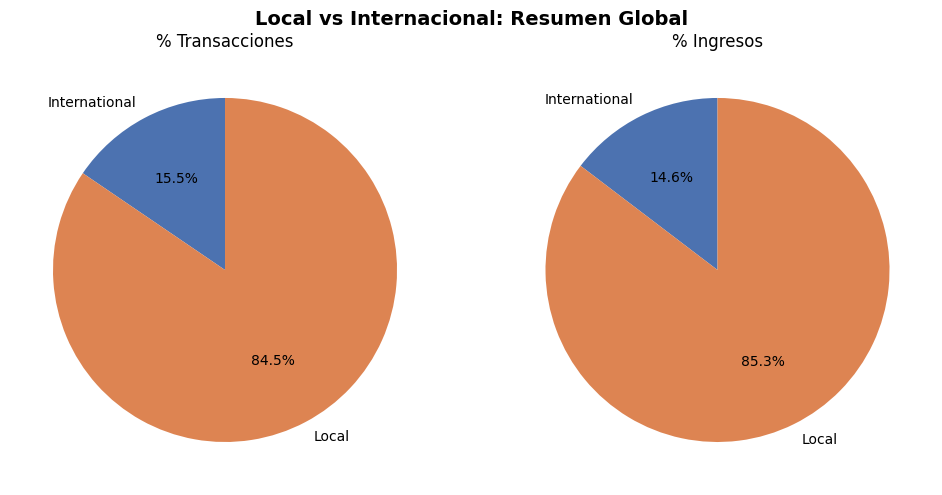

In [ ]:
# Gráfico

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Local vs Internacional: Resumen Global", fontsize=14, fontweight='bold')

for ax, col, title in zip(axes,
                          ['pct_transacciones', 'pct_ingresos'],
                          ['% Transacciones', '% Ingresos']):
    ax.pie(resumen_global[col],
           labels = resumen_global['compra_local'],
           autopct = '%1.1f%%', startangle=90,
           colors = ['#4C72B0', '#DD8452'])
    ax.set_title(title)

plt.tight_layout()
plt.show()

"""El peso de las transacciones internacionales versus las locales muestra
hasta qué punto el negocio depende de clientes que compran fuera de su país."""

In [ ]:
# Analizamos por país de la compañía, separamos local e internacional

def analisis_pais_compania(df):
    agrupado = df.groupby(['company_country', 'compra_local']).agg(
        ingresos=('amount', 'sum')
    ).reset_index()

    pivot = agrupado.pivot_table(index='company_country',
                                columns='compra_local',
                                values='ingresos',
                                aggfunc='sum').fillna(0)
    pivot.columns = ['International', 'Local']
    pivot['total'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('total', ascending=False)
    pivot['pct_local'] = (pivot['Local'] / pivot['total'] * 100).round(1)
    return pivot

company_pivot = analisis_pais_compania(df_geo)
print(company_pivot.head(10))


                 International       Local       total  pct_local
company_country                                                  
Sweden               230301.35  4697988.89  4928290.24       95.3
Netherlands          199310.20  4307261.18  4506571.38       95.6
United Kingdom       178179.72  3920937.36  4099117.08       95.7
Italy                198402.22  3889155.16  4087557.38       95.1
Germany              176608.83  3843755.24  4020364.07       95.6
France                65683.04  1350401.22  1416084.26       95.4
United States        631054.47   470682.80  1101737.27       42.7
Belgium              529649.61   422559.14   952208.75       44.4
Norway               445312.64   363976.18   809288.82       45.0
Ireland              390894.37   324326.09   715220.46       45.3


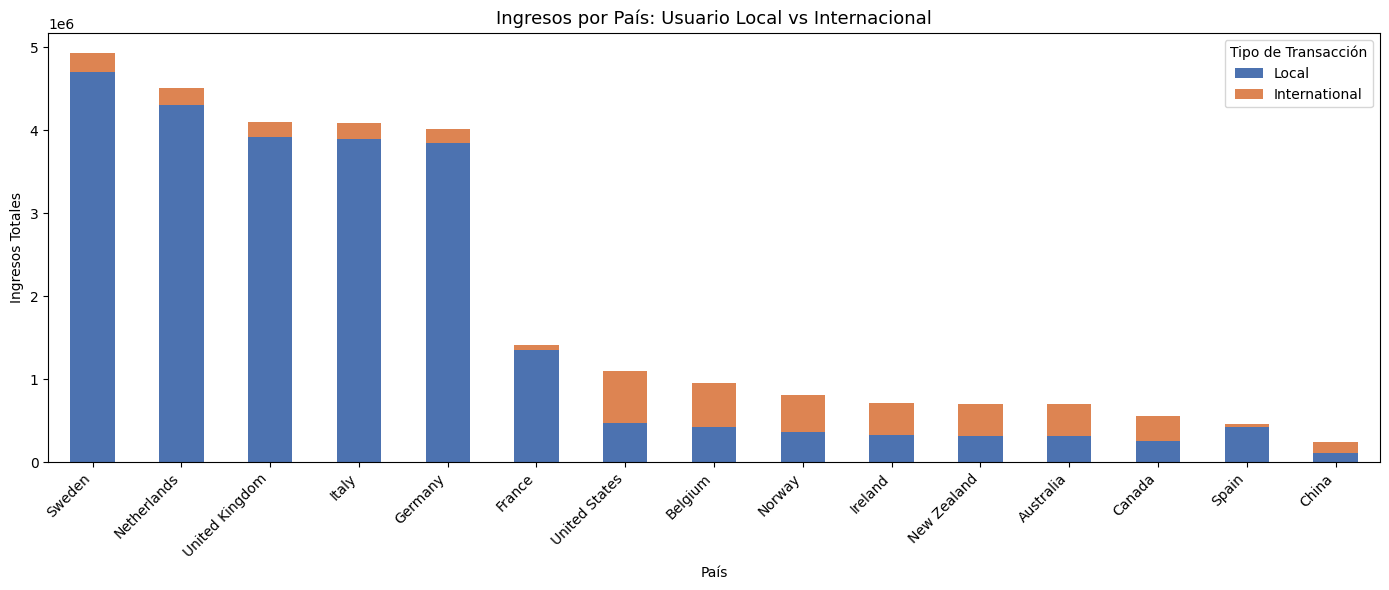

In [ ]:
# Gráfico de barras - Top 15

top15 = company_pivot.head(15)
top15[['Local', 'International']].plot(
    kind='bar', stacked=True, figsize=(14, 6),
    color=['#4C72B0', '#DD8452']
)
plt.title("Ingresos por País: Usuario Local vs Internacional", fontsize=13)
plt.xlabel("País")
plt.ylabel("Ingresos Totales")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Tipo de Transacción")
plt.tight_layout()
plt.show()

"""Algunos países (todo el top 6) dependen casi exclusivamente de ingresos
locales, mientras otros tienen un peso internacional relevante, a pesar de tener
menores ingresos, lo cual invita a estrategias de crecimiento distintas según
el país."""

In [ ]:
def main():
    df_transactions = pd.read_csv("N1-Ex.8__transactions.csv", sep=';')
    df_companies = pd.read_csv("N1-Ex.8__companies.csv")

    df_geo = crear_geo_df(df_transactions, df_companies)
    resumen_global = analisis_global_local(df_geo)
    company_pivot = analisis_pais_compania(df_geo)

    print("Resumen Global")
    print(resumen_global)
    print()
    print("Por País")
    print(company_pivot.head(10))

main()


Resumen Global
    compra_local  num_transacciones  ingreso_total  pct_transacciones  \
0  International              15486     4293172.12              15.49   
1          Local              84514    25002302.23              84.51   

   pct_ingresos  
0         14.65  
1         85.35  

Por País
                 International       Local       total  pct_local
company_country                                                  
Sweden               230301.35  4697988.89  4928290.24       95.3
Netherlands          199310.20  4307261.18  4506571.38       95.6
United Kingdom       178179.72  3920937.36  4099117.08       95.7
Italy                198402.22  3889155.16  4087557.38       95.1
Germany              176608.83  3843755.24  4020364.07       95.6
France                65683.04  1350401.22  1416084.26       95.4
United States        631054.47   470682.80  1101737.27       42.7
Belgium              529649.61   422559.14   952208.75       44.4
Norway               445312.64   363976.1

## Nivell 3 - Visualització executiva i storytelling

### Exercici 1: Mini-dashboard departamental

Construeix un mini-dashboard en Python utilitzant Google Colab. Aquest exercici està pensat perquè tot el desenvolupament principal es faci dins del notebook, utilitzant Colab com a eina d'anàlisi i visualització.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Cargamos, unimos y extraemos lo que necesitamos para el dashboard

def carga_prepara():
    df_tx = pd.read_csv("N1-Ex.8__transactions.csv", sep=';')
    df_comp = pd.read_csv("N1-Ex.8__companies.csv")

    df = df_tx.merge(df_comp[['company_id', 'country']],
                              left_on='business_id',
                              right_on='company_id',
                              how='left')

    df.rename(columns={'country': 'company_country'}, inplace=True)

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month
    df['year_month'] = df['timestamp'].dt.to_period('M')
    df['hour'] = df['timestamp'].dt.hour
    mapa_dias = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
    df['day_of_week'] = df['timestamp'].dt.weekday.map(mapa_dias)
    return df

df = carga_prepara()
print(df.shape)
print(df[['timestamp', 'year_month', 'hour', 'day_of_week', 'company_country']].head(3))


(100000, 26)
            timestamp year_month  hour day_of_week company_country
0 2018-12-12 08:05:17    2018-12     8   Miércoles           Spain
1 2024-05-20 22:49:08    2024-05    22       Lunes          Sweden
2 2018-11-04 23:16:18    2018-11    23     Domingo           Italy


In [ ]:
# Preparamos las cuatro funciones de agregación

# Gráfico de evolución de ingreso mensual

def prep_ingreso_mensual(df):
    mensual = (df.groupby('year_month')['amount']
                 .sum()
                 .reset_index()
                 .sort_values('year_month'))
    mensual['year_month_str'] = mensual['year_month'].astype(str)
    return mensual

# Gráfico Ingreso total por canal de venta

def prep_ingreso_canal(df):
    return (df.groupby('channel')['amount']
              .sum()
              .sort_values(ascending=False)
              .reset_index())

# Gráfico Top 10 ingresos por país

def prep_top_paises(df):
    return (df.groupby('company_country')['amount']
              .sum()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())

# Gráfico Actividad por día de la semana y hora

def prep_mapa_calor(df):
    orden_dia = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
    mapa_calor = pd.crosstab(df['day_of_week'], df['hour'])
    mapa_calor = mapa_calor.reindex(orden_dia)
    return mapa_calor


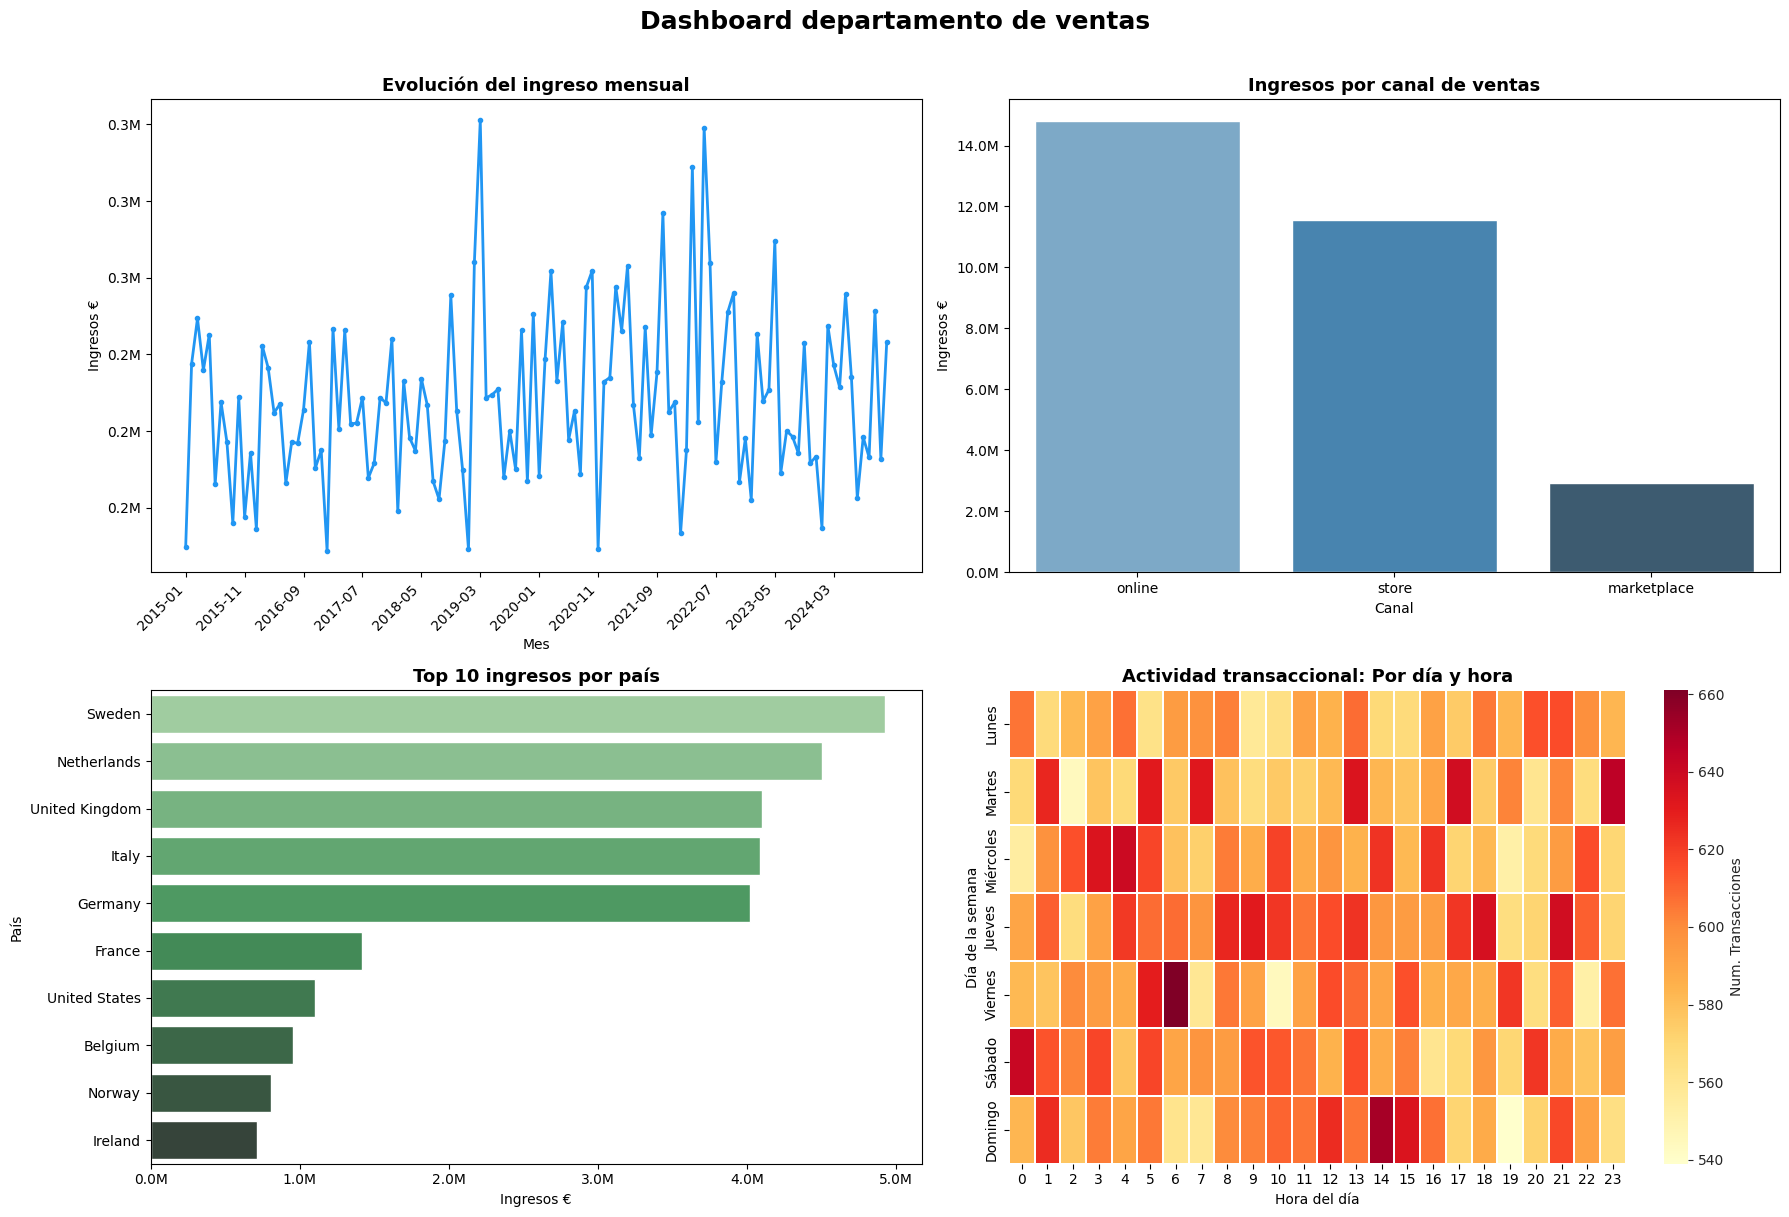

In [ ]:
# Creamos el dashboard del departamento de ventas

def crear_dashboard_ventas(df):

    # Preparamos

    mensual = prep_ingreso_mensual(df)
    por_canal = prep_ingreso_canal(df)
    por_pais = prep_top_paises(df)
    mapa_calor = prep_mapa_calor(df)

    # Damos forma

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle("Dashboard departamento de ventas", fontsize=18, fontweight='bold', y=1.01)
    sns.set_style("whitegrid")

    # Gráfico ingreso mensual

    ax1 = axes[0, 0]
    ax1.plot(mensual['year_month_str'], mensual['amount'],
             color='#2196F3', linewidth=2, marker='o', markersize=3)
    ax1.set_title("Evolución del ingreso mensual", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Mes")
    ax1.set_ylabel("Ingresos €")
    tick_step = max(1, len(mensual) // 12)
    ax1.set_xticks(range(0, len(mensual), tick_step))
    ax1.set_xticklabels(mensual['year_month_str'].iloc[::tick_step], rotation=45, ha='right')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

    # Gráfico ingreso por canal de venta

    ax2 = axes[0, 1]
    sns.barplot(data=por_canal, x='channel', y='amount', ax=ax2,
                palette='Blues_d', hue='channel', legend=False)
    ax2.set_title("Ingresos por canal de ventas", fontsize=13, fontweight='bold')
    ax2.set_xlabel("Canal")
    ax2.set_ylabel("Ingresos €")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

    # Gráfico países top 10

    ax3 = axes[1, 0]
    sns.barplot(data=por_pais, x='amount', y='company_country', ax=ax3,
                palette='Greens_d', hue='company_country', legend=False)
    ax3.set_title("Top 10 ingresos por país", fontsize=13, fontweight='bold')
    ax3.set_xlabel("Ingresos €")
    ax3.set_ylabel("País")
    ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

    # Mapa de calor de actividad

    ax4 = axes[1, 1]
    sns.heatmap(mapa_calor, ax=ax4, cmap='YlOrRd',
                linewidths=0.3, cbar_kws={'label': 'Num. Transacciones'})
    ax4.set_title("Actividad transaccional: Por día y hora", fontsize=13, fontweight='bold')
    ax4.set_xlabel("Hora del día")
    ax4.set_ylabel("Día de la semana")

    plt.tight_layout()
    plt.show()

crear_dashboard_ventas(df)


### Exercici 2: Informe executiu

Objectiu: A partir del dashboard, presenta un informe executiu en dues versions:

- Sense IA:

  Redactada amb les teves pròpies paraules.

- Amb suport d'IA:

  Utilitzant eines d'IA per:

  Millorar la redacció.

  Adaptar el llenguatge al departament escollit.

  Incorporar vocabulari tècnic de negoci.

Versión sin IA

Resumen general.

En el dashboard analizamos la actividad comercial de la empresa, el objetivo es entender cómo se distribuyen los ingresos por canal de venta, por país y por franja horaria, identificar si hay dependencias riesgosas y proponer acciones orientadas a ventas.

Hallazgos.

El canal de venta online genera poco más de 5 veces lo que genera el marketplace. La facturación está muy concentrada en el canal online, esto representa un riesgo en caso de que este canal falle por alguna razón.

La evolución de ingresos mensual es muy variable en el tiempo, con alzas notables en 2019 y 2022. No existe una tendencia clara de crecimiento, lo que sugiere que el volumen de ventas depende más de eventos puntuales que de una base sólida en aumento.

Los cinco primeros países del top 10 concentran casi toda la facturación principal. A partir del sexto puesto disminuye radicalmente. La empresa depende en gran medida de estos 5 países.

La actividad transaccional aumenta considerablemente los martes y los viernes en las franjas horarias matutinas y vespertinas (5 - 8 y 13 - 17). En menor medida los miércoles y los domingos.

Riesgos detectados.

Gran dependencia en el canal online, si, por ejemplo, se presentara una caída técnica del sitio web, el impacto sería severo.

La concentración de los ingresos en solo cinco países podría ser un gran riesgo, por ejemplo, debido a un cambio regulatorio.

El marketplace está muy subutilizado con 2,8 MM de ventass versus el canal online con aproximadamente 14,5 MM.

Oportunidades.

Activar campañas comerciales en las franjas horarias de mayor actividad para maximizar conversión en los momentos que ya funcionan.

Fortalecer la presencia en países del top 10 con menores ingresos actualmente, donde ya hay buena actividad pero con gran potencial de crecimiento.

Impulsar el canal marketplace con estrategias específicas para buscar equilibrar con el canal online.

Investigar si los picos puntuales de 2019 y 2022 fueron resultados de campañas específicas para que, en caso positivo, se repliquen estas acciones.

Recomendaciones.

Diversificación de canales de venta. Diseñar un plan para aumentar la cuota de facturación del marketplace.

Reforzar equipos comerciales y campañas durante las franjas horarias y días de mayor actividad transaccional.

Expandir presencia comercial en los países del top 10 que tadavía están por debajo de su potencial.

Identificar el orígen de los picos de ingresos del 2019  y 2022 para utilizar estos eventos puntuales en palancas comerciales.







Versión con IA

Resumen general.

El presente informe ejecutivo sintetiza los principales hallazgos obtenidos a partir del análisis de la actividad comercial correspondiente al período 2015–2024, con un total de 28.481 transacciones registradas. El análisis se ha estructurado en torno a cuatro dimensiones clave: evolución temporal de ingresos, distribución por canal de ventas, concentración geográfica y patrones de actividad transaccional por franja horaria. El objetivo es proporcionar al departamento de Ventas / Comercial una base sólida para la toma de decisiones estratégicas orientadas al crecimiento sostenible y la reducción de riesgos de concentración.

Hallazgos.

- El canal online lidera la facturación con aproximadamente 14,5M€, representando aproximadamente el 52% del total, frente al canal store (aproximadamente 11,5M€) y al marketplace (~2,8M€). Esta estructura refleja una dependencia operativa significativa de un único canal digital.
- La serie temporal de ingresos mensuales no evidencia una tendencia de crecimiento sostenido durante la década analizada. Se identifican picos de facturación aislados (2019, 2022) compatibles con acciones comerciales puntuales o campañas estacionales, pero sin consolidación en la base de ingresos recurrentes.
- La facturación geográfica presenta una marcada concentración en cinco mercados europeos: Suecia, Países Bajos, Reino Unido, Italia y Alemania, que aglutinan la mayor parte de los ingresos del top 10. Los mercados de segunda línea (Francia, EE.UU., Bélgica, Noruega, Irlanda) muestran una contribución significativamente inferior, señalando oportunidades de desarrollo comercial latente.
- El análisis de actividad transaccional por día y hora revela dos ventanas de alta intensidad: 6–8h y 13–15h, con mayor concentración de martes a viernes. Los domingos y las primeras horas de la madrugada registran la actividad más baja, con valores inferiores a 560 transacciones por celda.

Riesgos detectados.

- Sobreexposición al canal online: la elevada concentración de ingresos en un único canal digital implica una vulnerabilidad estructural ante disrupciones tecnológicas, cambios en algoritmos de adquisición o incrementos en costes de captación digital.
- Concentración geográfica de alto riesgo: la dependencia de cinco mercados europeos expone el negocio a shocks macroeconómicos o regulatorios regionales con impacto directo y desproporcionado en la cuenta de resultados.
- Estancamiento del volumen de ventas: la ausencia de una tendencia alcista clara en la serie temporal de ingresos mensuales indica que el crecimiento se sustenta en eventos puntuales y no en una expansión orgánica de la base de clientes o del ticket medio.
- Infrautilización del canal marketplace: con una facturación de apenas ~2,8M€ frente a los ~14,5M€ del canal online, el marketplace representa un canal con capacidad ociosa significativa y potencial de monetización no activado.

Oportunidades.

- Optimización de la ejecución comercial en ventanas de alta actividad: concentrar recursos, campañas y acciones de activación en las franjas 6–8h y 13–15h de martes a viernes maximizaría la tasa de conversión aprovechando la demanda ya existente.
- Desarrollo de mercados de segunda línea: Francia, Bélgica e Irlanda presentan actividad registrada pero con contribución reducida, lo que sugiere mercados con demanda latente susceptibles de ser desarrollados con inversión comercial focalizada.
- Activación estratégica del canal marketplace: incrementar la cuota del marketplace mediante acuerdos preferenciales, visibilidad diferencial o pricing específico reduciría la dependencia del canal online y diversificaría el riesgo de canal.
- Replicabilidad de picos históricos: el análisis de los picos de 2019 y 2022 puede revelar palancas comerciales probadas (campañas, promociones, eventos) que, sistematizadas, podrían generar crecimientos recurrentes en lugar de puntuales.

Recomendaciones.

- Diseñar un plan de diversificación de canales con objetivo explícito de incrementar la cuota del marketplace hasta el 15–20% de la facturación total en un horizonte de 12–18 meses.
- Alinear la planificación de recursos comerciales y campañas de activación con los patrones horarios y de día identificados, priorizando las franjas de máxima demanda.
- Establecer una hoja de ruta de expansión geográfica en mercados europeos de segunda línea con demanda probada pero presencia comercial aún insuficiente.
- Implementar un modelo de seguimiento mensual de concentración de ingresos por canal y país, con alertas tempranas ante desviaciones que incrementen la exposición a riesgos de concentración ya identificados.